# Ayudantía 2. ¿Qué pasa si utilizamos el modelo de regresión lineal en el caso en que Y es binaria?

Cuando una variable cualitativa con dos niveles (binaria) se codifica como 0 y 1, es posible ajustar un modelo de regresión lineal por mínimos cuadrados. Sin embargo, esta aproximación presenta dos inconvenientes principales:

* Al generar una recta (o un hiperplano si existen múltiples variables), las predicciones pueden tomar valores distintos de 0 y 1, lo que contradice la naturaleza binaria de la variable respuesta.

* Si se intenta interpretar las predicciones como probabilidades de pertenecer a una clase, estas podrían quedar fuera del intervalo, violando la definición de probabilidad.

Para evitar estas limitaciones, la regresión logística (Cox, 1958) aplica una transformación al valor obtenido por la regresión lineal mediante una función cuyo resultado siempre se encuentra entre 0 y 1. Entre estas funciones, la más común es la función logit.

$$p(X) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 X_1 + \cdots + \beta_p X_p)}}$$

De esta forma, el modelo puede interpretarse probabilísticamente y ajustarse para tareas de clasificación binaria, garantizando que todas las predicciones sean válidas como probabilidades.

En esta ayudantía trabajaremos con un caso práctico de clasificación binaria empleando el conjunto de datos Social_Network_Ads, disponible en: https://www.kaggle.com/code/charmanderoled/fork-of-regresion-logistica/input?select=Social_Network_Ads.csv.

Este dataset contiene información de usuarios de una red social e indica si compraron o no un producto publicitado.

Las variables incluidas son: User ID, Gender, Age, EstimatedSalary y Purchased, siendo Purchased la variable objetivo (0 = no compró, 1 = sí compró).

Vamos a construir entonces un modelo de regresión logística que estime la probabilidad de que un usuario compre el producto

## Observación

* Por lo general, si queremos construir un buen modelo debemos verificar que se cumplen las asunciones sobre las que se basa su desarrollo matemático:
    - No colinealidad o multicolinealidad (Análisis de correlaciones y VIF)
    - Relación lineal entre los predictores numéricos y el logaritmo de odds de la variable respuesta (Test de Box-Tidwell)
    - Independencia (Para este ejemplo consideramos que cada observación representa a un usuario distinto, por lo tanto se considera que las observaciones son independientes.)
    - Valores atípicos, con alto leverage o influyentes (Análisis gráfico de las distribuciones y método IQR si es necesario)
    - Parsimonia (Pueden analizar el poder predictivo de las variables o también pueden ir construyendo modelos desde el mas simple, con una variable hasta el mas complejo y al final si es necesario aplicar regularización).

# Librerías

In [42]:
# Tratamiento de datos
import pandas as pd
import numpy as np

# Gráficos
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesado y modelado
from scipy.stats import chi2
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools import add_constant
from patsy import dmatrices 
from sklearn.metrics import f1_score, matthews_corrcoef
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, confusion_matrix
from sklearn.metrics import roc_curve, auc, classification_report


# Configuración opcional de gráficos
plt.style.use("default") 
sns.set(style="whitegrid", context="notebook") # fondo blanco y cuadrícula ligera

# Configuración warnings
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)


# Cargar el dataset

In [2]:
df = pd.read_csv("Social_Network_Ads.csv")
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


## Información general del dataset

In [3]:
print("Dimensiones del dataset:", df.shape)
print("\nTipos de datos:")
print(df.info())


Dimensiones del dataset: (400, 5)

Tipos de datos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB
None


- `User ID` es solo un identificador así que no la usaremos en nuestro análisis
- `Gender` es una variable categórica (luego habrá que codificar).
- `Age` y `EstimatedSalary` son variables numéricas (enteras).
- `Purchased` es nuestra variable objetivo: 
    - 0 si el usuario **no** compró 
    - 1 si **sí** compró.

# Valores faltantes y duplicados

In [4]:
print("\nValores faltantes por columna:")
print(df.isna().sum())
print("\nDuplicados:")
print(df.duplicated().sum())


Valores faltantes por columna:
User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

Duplicados:
0


# Análisis exploratorio de las variables.

## Variables categóricas

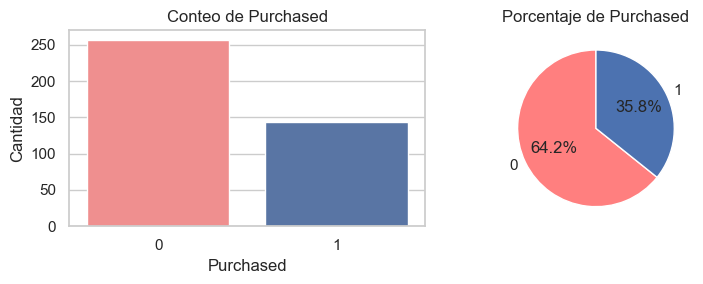

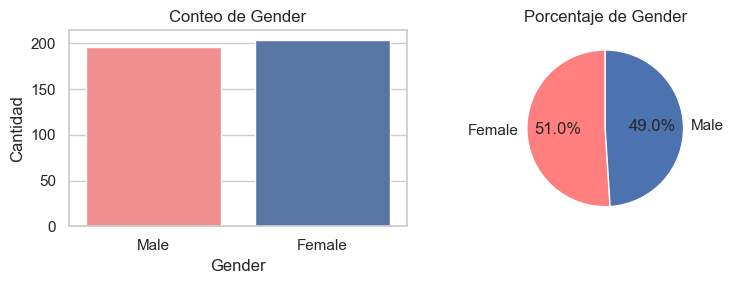

In [5]:
# Para la variable Purchased
fig, axes = plt.subplots(1, 2, figsize=(8, 3))

# Gráfico de barras (conteo)
sns.countplot(x="Purchased", data=df, ax=axes[0], palette=["#FF7F7F","#4C72B0"])
axes[0].set_title("Conteo de Purchased")
axes[0].set_xlabel("Purchased")
axes[0].set_ylabel("Cantidad")

# Gráfico de pastel (porcentaje)
purchased_counts = df["Purchased"].value_counts()
purchased_labels = purchased_counts.index
axes[1].pie(purchased_counts, labels=purchased_labels, autopct='%1.1f%%', startangle=90, colors=["#FF7F7F","#4C72B0"])
axes[1].set_title("Porcentaje de Purchased")

plt.tight_layout()
plt.show()

# Para la variable Gender
fig, axes = plt.subplots(1, 2, figsize=(8, 3))

# Gráfico de barras (conteo)
sns.countplot(x="Gender", data=df, ax=axes[0], palette=["#FF7F7F","#4C72B0"])
axes[0].set_title("Conteo de Gender")
axes[0].set_xlabel("Gender")
axes[0].set_ylabel("Cantidad")

# Gráfico de pastel (porcentaje)
gender_counts = df["Gender"].value_counts()
gender_labels = gender_counts.index
axes[1].pie(gender_counts, labels=gender_labels, autopct='%1.1f%%', startangle=90, colors=["#FF7F7F","#4C72B0"])
axes[1].set_title("Porcentaje de Gender")

plt.tight_layout()
plt.show()

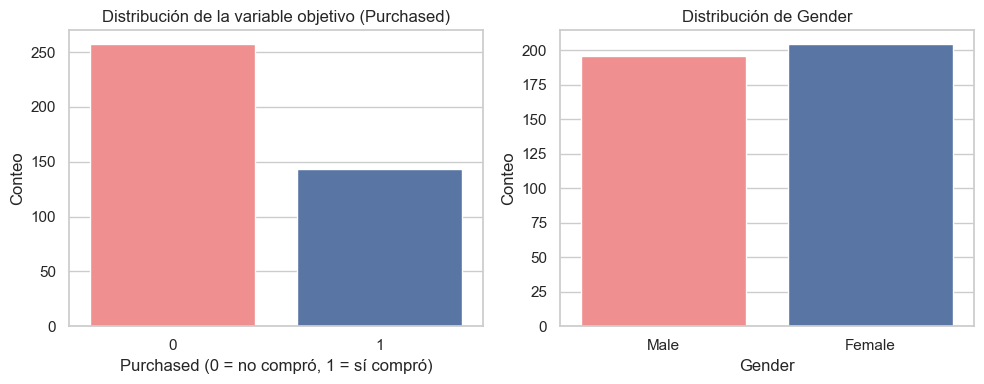

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.countplot(
    x    = "Purchased",
    data = df,
    palette=["#FF7F7F","#4C72B0"],
    ax   = axes[0]
)
axes[0].set_title("Distribución de la variable objetivo (Purchased)")
axes[0].set_xlabel("Purchased (0 = no compró, 1 = sí compró)")
axes[0].set_ylabel("Conteo")

sns.countplot(
    x    = "Gender",
    data = df,
    palette=["#FF7F7F","#4C72B0"],
    ax   = axes[1]
)
axes[1].set_title("Distribución de Gender")
axes[1].set_xlabel("Gender")
axes[1].set_ylabel("Conteo")

plt.tight_layout()
plt.show()


El 64.25% no compran y el 35.75% sí compra. Un modelo de clasificación que sea útil debe de ser capaz de predecir correctamente un porcentaje de observaciones por encima del porcentaje de la clase mayoritaria. En este caso, el umbral de referencia que se tiene que superar es del 64.25%.

## Variables numéricas

In [7]:
# Estadísticas descriptivas de variables numéricas
df.describe()

,User ID,Age,EstimatedSalary,Purchased
count,4.000000e+02,400.000000,400.000000,400.000000
mean,1.569154e+07,37.655000,69742.500000,0.357500
std,7.165832e+04,10.482877,34096.960282,0.479864
min,1.556669e+07,18.000000,15000.000000,0.000000
25%,1.562676e+07,29.750000,43000.000000,0.000000
50%,1.569434e+07,37.000000,70000.000000,0.000000
75%,1.575036e+07,46.000000,88000.000000,1.000000
max,1.581524e+07,60.000000,150000.000000,1.000000


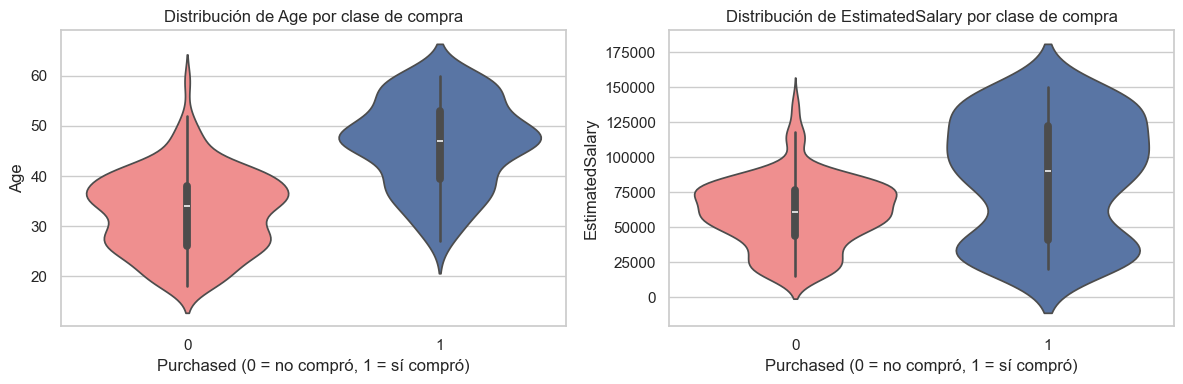

In [8]:
# Lista de variables numéricas
num_cols = ["Age", "EstimatedSalary"]

fig, axes = plt.subplots(1, len(num_cols), figsize=(6 * len(num_cols), 4))

if len(num_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, num_cols):
    sns.violinplot(
        x    = "Purchased",
        y    = col,
        data = df,
        palette = ["#FF7F7F", "#4C72B0"],
        ax   = ax
    )
    ax.set_title(f"Distribución de {col} por clase de compra")
    ax.set_xlabel("Purchased (0 = no compró, 1 = sí compró)")
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()


* En los gráficos tipo violín se observa que la distribución de `Age` es distinta según la clase de `Purchased`:
  - Cuando `Purchased = 0`, la edad se concentra más en el rango de adultos jóvenes (alrededor de 20–40 años).
  - Cuando `Purchased = 1`, la distribución se desplaza hacia edades mayores, con una concentración importante entre los 40 y 55 años aproximadamente.

* Para `EstimatedSalary` visiblemente no se puede distinguir tan explícitamente como en `Age`:
  - Cuando `Purchased = 0`, los salarios se concentran en un rango entre 35000 y 75000 aproximadamente.
  - Cuando `Purchased = 1`, la distribución se extiende más hacia salarios altos (El rango está entre 35000 y 125000 aproximadamente).

* Además que no se nota presencia de outliers.


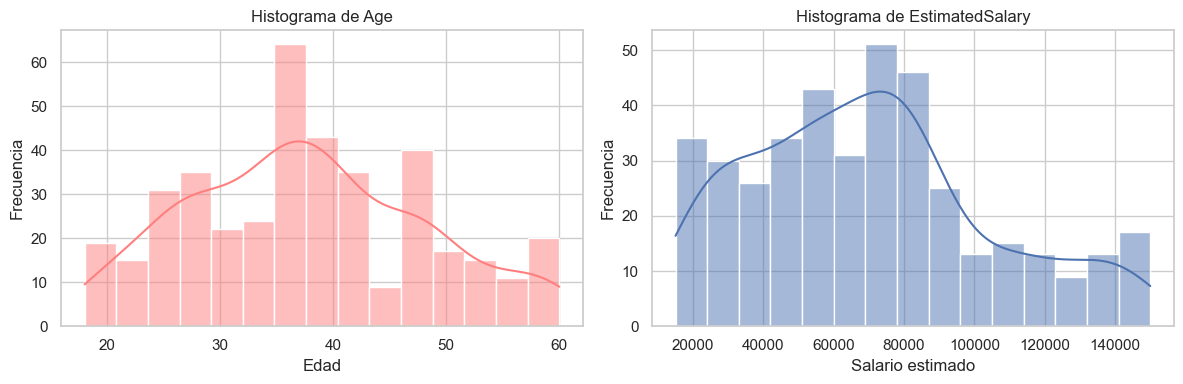

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma de Age
sns.histplot(
    data=df,
    x="Age",
    bins=15,
    kde=True,
    color = "#FF7F7F",
    ax=axes[0]
)
axes[0].set_title("Histograma de Age")
axes[0].set_xlabel("Edad")
axes[0].set_ylabel("Frecuencia")

# Histograma de EstimatedSalary
sns.histplot(
    data=df,
    x="EstimatedSalary",
    bins=15,
    kde=True,
    color = "#4C72B0",
    ax=axes[1]
)
axes[1].set_title("Histograma de EstimatedSalary")
axes[1].set_xlabel("Salario estimado")
axes[1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()


- `Age` muestra una distribución relativamente concentrada, con una forma que se acerca a unimodal y sin colas muy largas. No se aprecia una asimetría extrema; la masa principal está en un rango razonable de adultos.

- `EstimatedSalary` es menos simétrica. La cola (derecha) hacia valores altos es más larga. La asimetría no es muy fuerte.

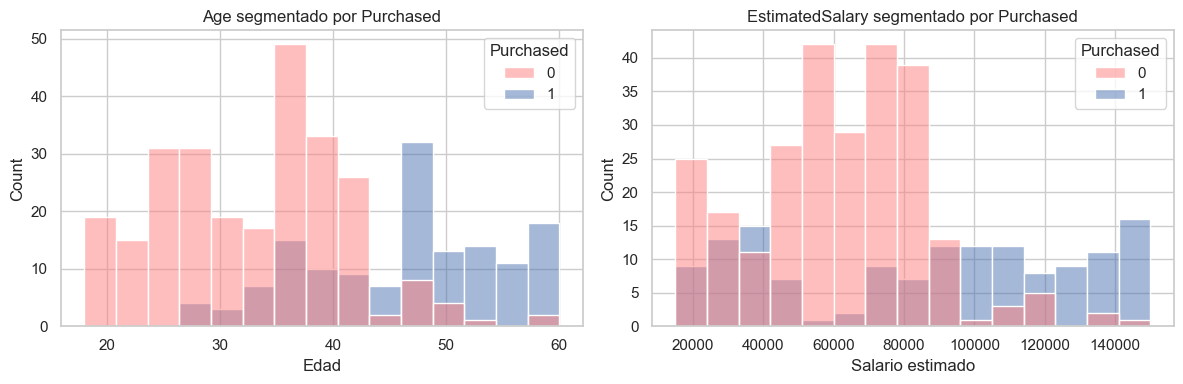

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(
    data=df,
    x="Age",
    hue="Purchased",
    bins=15,
    kde=False,
    palette = ["#FF7F7F", "#4C72B0"],
    ax=axes[0]
)
axes[0].set_title("Age segmentado por Purchased")
axes[0].set_xlabel("Edad")

sns.histplot(
    data=df,
    x="EstimatedSalary",
    hue="Purchased",
    bins=15,
    kde=False,
    palette = ["#FF7F7F", "#4C72B0"],
    ax=axes[1]
)
axes[1].set_title("EstimatedSalary segmentado por Purchased")
axes[1].set_xlabel("Salario estimado")

plt.tight_layout()
plt.show()


- En `Age`, los usuarios que **no compran** (`Purchased = 0`) se concentran más en edades bajas y medias, mientras que los que **sí compran** (`Purchased = 1`) aparecen con más fuerza en edades altas. Podemos ver en la gráfica que a medida que aumenta la edad, el color azul gana presencia frente al rojo.

- En `EstimatedSalary`, algo similar ocurre con el salario: en tramos medios domina el rojo, pero en los tramos altos la presencia de azul es mayor. Los salarios muy altos casi siempre se asocian con `Purchased = 1`.

En conjunto, los gráficos indican que tanto la edad como el salario ayudan a distinguir entre compradores y no compradores.


# Análisis multivariado. 

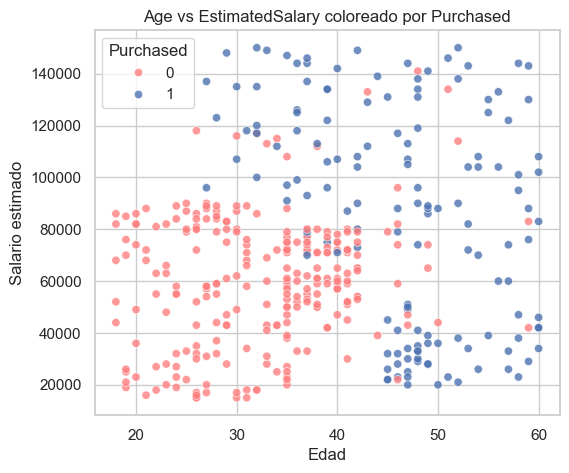

In [11]:
# Relación entre Age Vs EstimatedSalary por Purchased
plt.figure(figsize=(6, 5))

sns.scatterplot(
    data = df,
    x    = "Age",
    y    = "EstimatedSalary",
    hue  = "Purchased",
    palette = ["#FF7F7F", "#4C72B0"], 
    alpha = 0.8
)

plt.title("Age vs EstimatedSalary coloreado por Purchased")
plt.xlabel("Edad")
plt.ylabel("Salario estimado")
plt.show()



* Observamos que la variable Purchased tiende a separarse visualmente según la combinación de Age y EstimatedSalary, justificando el uso de ambos predictores en el modelo logístico.

In [12]:
# Gender vs Purchased
# Tabla de contingencia
ct = pd.crosstab(df["Gender"], df["Purchased"], margins=True)
ct

Purchased,0,1,All
Gender,,,
Female,127,77,204
Male,130,66,196
All,257,143,400


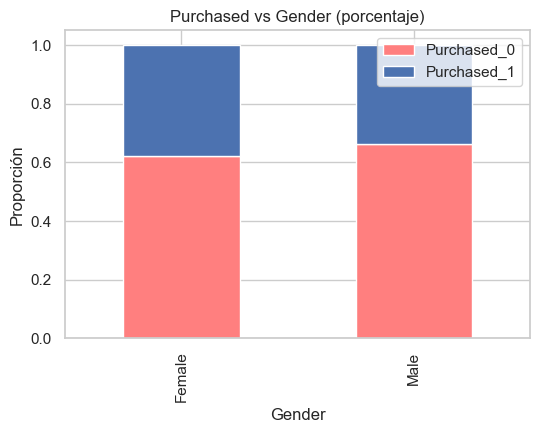

In [13]:
df_ct = pd.DataFrame({
    "Purchased_0": [127, 130],
    "Purchased_1": [77, 66]
}, index=["Female", "Male"])
df_ct["All"] = df_ct["Purchased_0"] + df_ct["Purchased_1"]

df_ct_prop = df_ct[["Purchased_0", "Purchased_1"]].div(df_ct["All"], axis=0)
df_ct_prop.plot(
    kind="bar",
    stacked=True,
    color=["#FF7F7F", "#4C72B0"],
    figsize=(6,4)
)
plt.title("Purchased vs Gender (porcentaje)")
plt.xlabel("Gender")
plt.ylabel("Proporción")
plt.show()

## Correlación

In [14]:
# Codificación one-hot de Gender (crea columnas dummy)
df = pd.get_dummies(df, columns=["Gender"], drop_first=True, dtype=int)
df.head()

,User ID,Age,EstimatedSalary,Purchased,Gender_Male
0,15624510,19,19000,0,1
1,15810944,35,20000,0,1
2,15668575,26,43000,0,0
3,15603246,27,57000,0,0
4,15804002,19,76000,0,1


In [15]:
# Matriz de correlaciones entre predictores numéricos
df[["Age", "EstimatedSalary", 'Gender_Male']].corr()

,Age,EstimatedSalary,Gender_Male
Age,1.000000,0.155238,-0.073741
EstimatedSalary,0.155238,1.000000,-0.060435
Gender_Male,-0.073741,-0.060435,1.000000


* La correlación es baja. No hay relación lineal fuerte entre edad y salario, así que por aquí no hay problema de colinealidad.

* Con respecto a la variable ``Gender_Male`` vemos que no hay dependencia significativa con las otras variables.

* Ya que las correlaciones presentes son todas muy cercanas a 0, se evidencia que las variables son independientes entre sí y no existe riesgo de multicolinealidad. 

## VIF (Variance Inflation Factor o Factor de Inflación de la Varianza)

El análisis VIF (Variance Inflation Factor o Factor de Inflación de la Varianza) sirve para detectar multicolinealidad entre las variables independientes de un modelo de regresión, incluyendo la regresión logística múltiple. El VIF para cada predictor se calcula como:

$$VIF_j = \frac{1}{1-R^{2}_{j}}$$
 
Donde $R^{2}_{j}$ es el coeficiente de determinación resultante de regredir el predictor $X_j$ contra todos los demás predictores del modelo.

Un VIF cercano a 1 significa  que hay cero colinealidad, es decir, cada variable está aportando información distinta. Valores entre 1 y 5 se consideran perfectamente aceptables. El VIF alto de const no nos importa; la constante no se interpreta como predictor.

In [16]:
X_num = df[["Age", "EstimatedSalary", "Gender_Male"]]
X_vif = add_constant(X_num)

vif_df = pd.DataFrame({
    "variable": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i)
            for i in range(X_vif.shape[1])]
})

vif_df


,variable,VIF
0,const,17.965792
1,Age,1.029078
2,EstimatedSalary,1.027234
3,Gender_Male,1.007960


##  Medir el poder predictivo de los atributos: WOE e IV

* WOE (Weight of Evidence) e IV (Information Value) son métricas para evaluar el poder de los atributos en distinguir entre las dos clases antes de construir un modelo de regresión logística.

* WOE cuantifica, para cada grupo de una variable, cuán distinta es la proporción de “no compran” (buenos) y “compran” (malos), usando el logaritmo del cociente de ambas proporciones por grupo.

* IV resume en un solo número el poder global de la variable para separar las clases; cuanto mayor el IV, mayor información aporta esa variable para predecir la variable objetivo.

* La interpretación estándar del IV es:
  - Menos de 0.02: sin poder predictivo
  - 0.02–0.1: poder débil
  - 0.1–0.3: poder medio
  - 0.3–0.5: poder fuerte
  - Mayor a 0.5: sospechoso (puede indicar sobreajuste o fuga de información)

* WOE e IV se calculan para variables continuas agrupadas en bins (Age, EstimatedSalary) y para categóricas (Gender_Male), ayudando a decidir qué variables usar y cómo tratarlas en modelos predictivos.

In [17]:
# Trabajamos con una copia solo con las columnas relevantes
df_woe = df[["Age", "EstimatedSalary", "Gender_Male", "Purchased"]].copy()

# Definimos buenos (0) y malos (1)
df_woe["good"] = (df_woe["Purchased"] == 0).astype(int)
df_woe["bad"]  = (df_woe["Purchased"] == 1).astype(int)

total_good = df_woe["good"].sum()
total_bad  = df_woe["bad"].sum()

print("Total good (Purchased=0):", total_good)
print("Total bad  (Purchased=1):", total_bad)


Total good (Purchased=0): 257
Total bad  (Purchased=1): 143


* Tenemos entonces 257 observaciones de “no compra” (número de buenos en el atributo Purchased=0) y 143 observaciones de “compra” (número de malos en el atributo Purchased=1). Esto implica que:
    - El 64.25% de las observaciones son “no compra” (257 de 400).
    - El 35.75% son “compra” (143 de 400).

* Hay cierto desbalance de clases, lo cual es típico en datos asociado a compras. Esto puede afectar nuestras métricas.

#### Binning de Age y tabla WOE/IV

Tabla WOE/IV para Age:


,Age_bin,n_obs,good,bad,dist_good,dist_bad,dist_good_adj,dist_bad_adj,woe,iv_bin
0,"(17.999, 28.0]",90,87,3,0.338521,0.020979,0.338521,0.020979,2.781064,0.883106
1,"(28.0, 35.0]",88,74,14,0.287938,0.097902,0.287938,0.097902,1.078776,0.205006
2,"(35.0, 40.0]",75,53,22,0.206226,0.153846,0.206226,0.153846,0.293018,0.015348
3,"(40.0, 47.0]",70,35,35,0.136187,0.244755,0.136187,0.244755,-0.586231,0.063646
4,"(47.0, 60.0]",77,8,69,0.031128,0.482517,0.031128,0.482517,-2.740896,1.237211



Information Value (Age): 2.4043


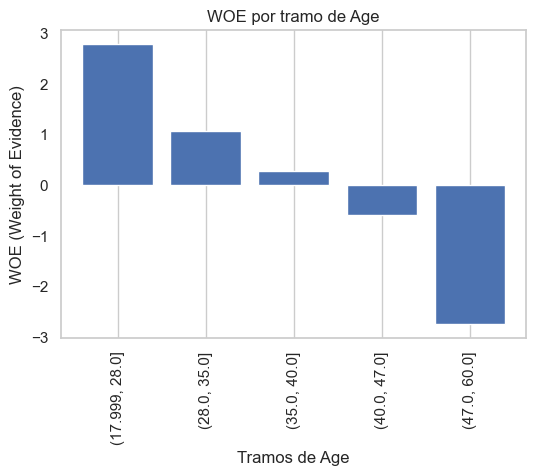

In [18]:
# Creamos tramos de Age (por ejemplo, 5 quantiles)
df_woe["Age_bin"] = pd.qcut(df_woe["Age"], q=5, duplicates="drop")

age_woe_table = (
    df_woe
    .groupby("Age_bin")
    .agg(
        n_obs  = ("Purchased", "count"),
        good   = ("good", "sum"),
        bad    = ("bad", "sum")
    )
    .reset_index()
)

# Distribuciones de buenos y malos
age_woe_table["dist_good"] = age_woe_table["good"] / total_good
age_woe_table["dist_bad"]  = age_woe_table["bad"]  / total_bad

# Evitar ceros (para no tener logaritmos infinitos)
eps = 1e-6
age_woe_table["dist_good_adj"] = age_woe_table["dist_good"].replace(0, eps)
age_woe_table["dist_bad_adj"]  = age_woe_table["dist_bad"].replace(0, eps)

# Cálculo de WOE
age_woe_table["woe"] = np.log(
    age_woe_table["dist_good_adj"] / age_woe_table["dist_bad_adj"]
)

# Cálculo de IV por tramo
age_woe_table["iv_bin"] = (
    (age_woe_table["dist_good"] - age_woe_table["dist_bad"])
    * age_woe_table["woe"]
)

# IV total para Age
iv_age = age_woe_table["iv_bin"].sum()

print("Tabla WOE/IV para Age:")
display(age_woe_table)

print(f"\nInformation Value (Age): {iv_age:.4f}")

plt.figure(figsize=(6,4))
plt.bar(age_woe_table["Age_bin"].astype(str), age_woe_table["woe"], color="#4C72B0")
plt.xlabel("Tramos de Age")
plt.ylabel("WOE (Weight of Evidence)")
plt.title("WOE por tramo de Age")
plt.xticks(rotation=90)
plt.grid(axis='y')
plt.show()


* El Information Value (IV) total para Age es alto (suma de la columna iv_bin = 2.4043): esto indica que la variable Age tiene un fuerte poder predictivo para discriminar compras.
* los menores de 18 son principalmente no compradores; los mayores de 47, principalmente compradores. El modelo logístico probablemente use este patrón para separar las clases.
* Los valores intermedios contribuyen menos al poder predictivo 

### WOE e IV para EstimatedSalary

In [19]:
# Binning de EstimatedSalary en 5 quantiles
df_woe["Salary_bin"] = pd.qcut(df_woe["EstimatedSalary"], q=5, duplicates="drop")

salary_woe_table = (
    df_woe
    .groupby("Salary_bin")
    .agg(
        n_obs  = ("Purchased", "count"),
        good   = ("good", "sum"),
        bad    = ("bad", "sum")
    )
    .reset_index()
)

salary_woe_table["dist_good"] = salary_woe_table["good"] / total_good
salary_woe_table["dist_bad"]  = salary_woe_table["bad"]  / total_bad

salary_woe_table["dist_good_adj"] = salary_woe_table["dist_good"].replace(0, eps)
salary_woe_table["dist_bad_adj"]  = salary_woe_table["dist_bad"].replace(0, eps)

salary_woe_table["woe"] = np.log(
    salary_woe_table["dist_good_adj"] / salary_woe_table["dist_bad_adj"]
)

salary_woe_table["iv_bin"] = (
    (salary_woe_table["dist_good"] - salary_woe_table["dist_bad"])
    * salary_woe_table["woe"]
)

iv_salary = salary_woe_table["iv_bin"].sum()

print("Tabla WOE/IV para EstimatedSalary:")
display(salary_woe_table)

print(f"\nInformation Value (EstimatedSalary): {iv_salary:.4f}")


Tabla WOE/IV para EstimatedSalary:


,Salary_bin,n_obs,good,bad,dist_good,dist_bad,dist_good_adj,dist_bad_adj,woe,iv_bin
0,"(14999.999, 37800.0]",80,49,31,0.190661,0.216783,0.190661,0.216783,-0.128398,0.003354
1,"(37800.0, 59000.0]",87,73,14,0.284047,0.097902,0.284047,0.097902,1.065171,0.198276
2,"(59000.0, 75000.0]",76,66,10,0.256809,0.069930,0.256809,0.069930,1.300838,0.243100
3,"(75000.0, 95200.0]",77,57,20,0.221790,0.139860,0.221790,0.139860,0.461088,0.037777
4,"(95200.0, 150000.0]",80,12,68,0.046693,0.475524,0.046693,0.475524,-2.320833,0.995247



Information Value (EstimatedSalary): 1.4778


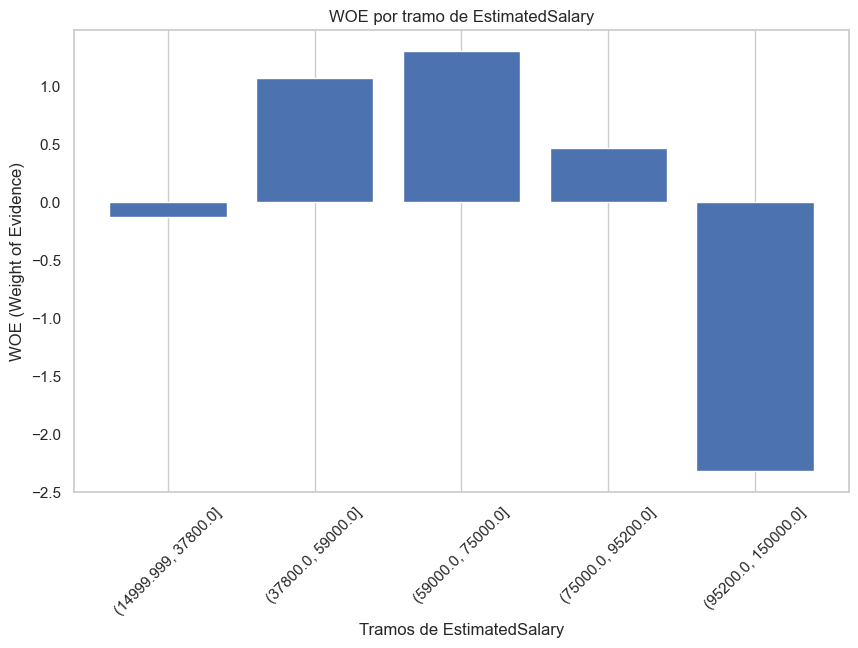

In [20]:
plt.figure(figsize=(10,6))
plt.bar(salary_woe_table["Salary_bin"].astype(str), salary_woe_table["woe"], color="#4C72B0")
plt.xlabel("Tramos de EstimatedSalary")
plt.ylabel("WOE (Weight of Evidence)")
plt.title("WOE por tramo de EstimatedSalary")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

* Al igual que con la edad, los tramos extremos de EstimatedSalary tienen mayor capacidad para diferenciar compradores de no compradores.
* La variable presenta un poder moderado a fuerte en la predicción de compra basado en IV total (aproximado suma IV = 1.4778).
* El tramo con salarios muy altos (último bin) está asociado fuertemente al grupo "compra".

### WOE e IV para Gender_Male

In [21]:
gender_woe_table = (
    df_woe
    .groupby("Gender_Male")
    .agg(
        n_obs  = ("Purchased", "count"),
        good   = ("good", "sum"),
        bad    = ("bad", "sum")
    )
    .reset_index()
)

gender_woe_table["dist_good"] = gender_woe_table["good"] / total_good
gender_woe_table["dist_bad"]  = gender_woe_table["bad"]  / total_bad

gender_woe_table["dist_good_adj"] = gender_woe_table["dist_good"].replace(0, eps)
gender_woe_table["dist_bad_adj"]  = gender_woe_table["dist_bad"].replace(0, eps)

gender_woe_table["woe"] = np.log(
    gender_woe_table["dist_good_adj"] / gender_woe_table["dist_bad_adj"]
)

gender_woe_table["iv_bin"] = (
    (gender_woe_table["dist_good"] - gender_woe_table["dist_bad"])
    * gender_woe_table["woe"]
)

iv_gender = gender_woe_table["iv_bin"].sum()

print("Tabla WOE/IV para Gender_Male:")
display(gender_woe_table)

print(f"\nInformation Value (Gender_Male): {iv_gender:.4f}")


Tabla WOE/IV para Gender_Male:


,Gender_Male,n_obs,good,bad,dist_good,dist_bad,dist_good_adj,dist_bad_adj,woe,iv_bin
0,0,204,127,77,0.494163,0.538462,0.494163,0.538462,-0.085850,0.003803
1,1,196,130,66,0.505837,0.461538,0.505837,0.461538,0.091648,0.004060



Information Value (Gender_Male): 0.0079


* Hay casi igualdad en la proporción de “buenos” (no compran) y “malos” (compran) entre hombres (1) y mujeres (0).
* Los valores de WOE están muy cerca de cero (-0.0859 para mujeres, 0.0916 para hombres), lo que confirma que no hay una diferencia relevante en la distribución de clases por género.
* Los valores individuales de IV por categoría son muy pequeños (0.0038 y 0.0041), sumando al total bajo (0.0079), por lo que no es una variable útil para separar las clases en este dataset.
* Su inclusión en el modelo puede no aportar información relevante y podría incluso añadir ruido.

## Relación lineal entre los predictores numéricos y el logaritmo de odds de la variable respuesta (logit)

Para verificar este supuesto, una prueba formal es el test de Box-Tidwell. El test de Box-Tidwell es una prueba estadística utilizada para verificar el supuesto de linealidad entre las variables predictoras continuas y el logit (logaritmo de las odds) en modelos de regresión logística.

El test consiste en agregar términos de la forma $X \cdot ln(X)$ para cada variable continua en el modelo. Matemáticamente, se añade como predictor el producto entre la variable continua $X$ y su logaritmo natural $ln(X)$. Si el coeficiente asociado a este término es significativo, indica que la relación entre esa variable y el logit no es lineal, sugiriendo que la suposición fundamental del modelo se viola y que se deben aplicar transformaciones o modelar la no linealidad.

In [22]:
for col in ['Age', 'EstimatedSalary']: 
    df[col+'_log'] = df[col] * np.log(df[col].replace(0, np.nan))

formula = 'Purchased ~ Age + EstimatedSalary + Gender_Male + Age_log + EstimatedSalary_log'

# Preparar matrices para statsmodels
y, X = dmatrices(formula, data=df, return_type='dataframe')

# Ajustar modelo de regresión logística con términos adicionales
model = sm.Logit(y, X)
result = model.fit()

# Mostrar resumen para revisar coeficientes de términos logarítmicos
print(result.summary())


Optimization terminated successfully.
         Current function value: 0.285209
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:              Purchased   No. Observations:                  400
Model:                          Logit   Df Residuals:                      394
Method:                           MLE   Df Model:                            5
Date:                Fri, 14 Nov 2025   Pseudo R-squ.:                  0.5625
Time:                        18:01:12   Log-Likelihood:                -114.08
converged:                       True   LL-Null:                       -260.79
Covariance Type:            nonrobust   LLR p-value:                 2.619e-61
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              -7.1361      8.119     -0.879      0.379     -23.049       8.777
Ag

* Para la variable ``Age`` y su término transformado ``Age_log``, se tiene un p-valor = 0.683, lo que sugiere que la relación entre Age y el logit puede considerarse aproximadamente lineal.

* Para la variable ``Gender_Male`` el p-valor = 0.158, lo que sugiere que la relación entre Age y el logit puede considerarse aproximadamente lineal.

* Para la variable ``EstimatedSalary`` y su término transformado ``EstimatedSalary_log``, el p-valor es 0, indicando que la relación entre EstimatedSalary y el logit no es lineal. Esto sugiere transformar EstimatedSalary o incluir términos polinomiales para modelar mejor su efecto.

* **Opcional:** Otra manera de analizar esta relación lineal es realizar una inspección intuitiva usando gráficos por intervalos (bin). Dividimos las variables predictoras ``Age`` y ``EstimatedSalary`` en tramos o intervalos, y observamos cómo varían la tasa de ``Purchased`` y el logit correspondiente en esos tramos.

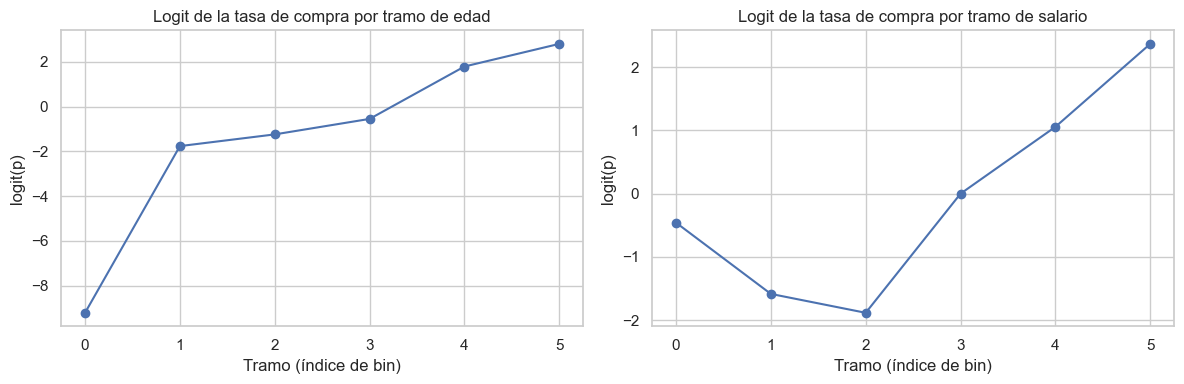

In [23]:
def tasa_y_logit_por_tramos(col, n_bins=6):
    cortes = pd.cut(df[col], bins=n_bins)
    resumen = (
        df.groupby(cortes)["Purchased"]
          .mean()
          .reset_index(name="purchase_rate")
    )
    # evitar 0 y 1 exactos para no tener logit infinito
    eps = 1e-4
    p = resumen["purchase_rate"].clip(eps, 1 - eps)
    resumen["logit_p"] = np.log(p / (1 - p))
    return resumen

age_logit = tasa_y_logit_por_tramos("Age", n_bins=6)
salary_logit = tasa_y_logit_por_tramos("EstimatedSalary", n_bins=6)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Edad
axes[0].plot(age_logit.index, age_logit["logit_p"], marker="o")
axes[0].set_title("Logit de la tasa de compra por tramo de edad")
axes[0].set_xlabel("Tramo (índice de bin)")
axes[0].set_ylabel("logit(p)")

# Salario
axes[1].plot(salary_logit.index, salary_logit["logit_p"], marker="o")
axes[1].set_title("Logit de la tasa de compra por tramo de salario")
axes[1].set_xlabel("Tramo (índice de bin)")
axes[1].set_ylabel("logit(p)")

plt.tight_layout()
plt.show()



* El gráfico para ``Age`` respalda la conclusión de que la relación entre ``Age`` y el logit de la probabilidad de ``Purchased`` puede considerarse lineal (se nota una tendencia casi lineal).
* En el gráfico para ``EstimatedSalary`` la curva presenta cambios de pendiente y no sigue un patrón lineal, sobre todo en los primeros tramos, confirmando la necesidad de transformar esta variable o modelar explicitamente su no linealidad.
* Por lo tanto aplicaremos la transformación logarítmica a la variable ``EstimatedSalary``

### Aplicar transformación logarítmica (sumar 1 para evitar log(0) si hay ceros)

In [24]:
df['EstimatedSalary_log'] = np.log(df['EstimatedSalary'] + 1)

# Construcción de los modelos

### Modelo que vamos a construir

* **Modelo 1: `Age`, `EstimatedSalary` y `Gender_Male`**

    $$
   \text{logit}(p_i) \;=\; \beta_0 
   \;+\; \beta_1 \cdot \text{Age}_i 
   \;+\; \beta_2 \cdot \text{EstimatedSalary}_i
   \;+\; \beta_3 \cdot \text{Gender\_Male}_i
   $$


donde:

- $p_i = \mathbb{P}(\text{Purchased}_i = 1 \mid \text{predictores})$
- $\text{logit}(p_i) = \log\left(\dfrac{p_i}{1 - p_i}\right)$
- El coeficiente \(\beta_3\) compara las **odds de compra** entre hombres y mujeres, manteniendo constantes la edad y el salario.
    * Si $\exp(\beta_3) > 1$, las odds de compra son mayores en hombres que en mujeres;
    * Si $\exp(\beta_3) < 1$, ocurre lo contrario.
 

## Dividir el dataset

In [25]:
X = df[['Age', 'EstimatedSalary_log', 'Gender_Male']]
y = df['Purchased']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size   = 0.8,
    random_state = 42,
    shuffle      = True,
    stratify     = y
)

## Escalar las variables

In [26]:
scaler = StandardScaler()

# Ajustar el escalador en train y transformar
X_train_scaled = scaler.fit_transform(X_train)

# Usar el mismo escalador en test
X_test_scaled = scaler.transform(X_test)

## Modelo 1

Vamos a usar las funciones de Scikit-Learn.

* Parámetros:

    - penalty: Tipo de regularización. Puede ser 'l1' (Lasso), 'l2' (Ridge, por defecto), 'elasticnet' (combinación) o None (sin regularización).
    - C: Inversa de la fuerza de regularización. Valores bajos = mayor regularización; valores altos = menos.
    - solver: Algoritmo para optimizar el modelo, ejemplos: 'liblinear', 'lbfgs', 'saga'.
    - max_iter: Número máximo de iteraciones para la optimización.
    - random_state: Semilla para reproducibilidad.

* Salidas que puedes obtener tras ajuste (fit)
    - coef_: Coeficientes estimados (para cada predictor $(\beta_j)$)
    - intercept_: Ordenada al origen $(\beta_0)$.
    - predict(X): Predicciones de clase (0 ó 1).
    - predict_proba(X): Probabilidades estimadas de pertenecer a cada clase.
    - score(X, y): Precisión (accuracy) del modelo en datos X e y.

In [27]:
# Ajuste del modelo
modelo1 = LogisticRegression(solver="lbfgs",
                             penalty = None,
                             max_iter = 1000,
                             random_state = 42
                             )
modelo1.fit(X_train_scaled, y_train)

# Información básica del modelo
print("Intercepto (β0):", modelo1.intercept_[0])
print("Coeficientes:", modelo1.coef_[0])

Intercepto (β0): -1.1555361514072695
Coeficientes: [2.2242966  1.06984154 0.10364961]


* El intercepto negativo indica la base log-odds para la clase "no compra" cuando todas las variables predictoras son cero
* Un coeficiente positivo para Age y EstimatedSalary indica que a medida que estas variables aumentan, aumenta la probabilidad de compra.
* El coeficiente pequeño para Gender_Male confirma su bajo poder predictivo, como vimos en WOE/IV.

### Odds y odds ratio como medidas de riesgo y de asociación

- **Probabilidad** de compra:$p_i = \mathbb{P}(\text{Purchased}_i = 1 \mid \text{predictores})$

- **Odds**: Las odds son la razón entre la probabilidad de compra y la de no compra:
  $$
  \text{odds}_i = \frac{p_i}{1 - p_i}
  $$
  Ejemplo: un valor de $\text{odds} = 3$, significa que la probabilidad de compra es tres veces la probabilidad de no comprar.

- **Odds ratio (OR)**: compara las odds entre dos grupos o dos niveles de un predictor. Por ejemplo, para `Gender_Male`:
  $$
  \text{OR} = \frac{\text{odds}(\text{hombre})}{\text{odds}(\text{mujer})}.
  $$

En el modelo, el OR asociado a una variable es:$\text{OR}_j = \exp(\beta_j)$, que mide el cambio multiplicativo en las odds por unidad de aumento en el predictor.
  - Si $\text{OR}_j > 1$, el predictor se asocia a **mayor riesgo** (odds más altas) del evento.
  - Si $\text{OR}_j < 1$, se asocia a **menor riesgo** (odds más bajas).


In [28]:
# Coeficientes y odds ratio
beta0_m1 = modelo1.intercept_[0]
betas_m1 = modelo1.coef_[0]

coef_m1_df = pd.DataFrame({
    "variable": ["Age", "EstimatedSalary_log", "Gender_Male"],
    "coef_beta": betas_m1,
    "odds_ratio": np.exp(betas_m1)
})

print("\nIntercepto (beta_0):", beta0_m1)
display(coef_m1_df)


Intercepto (beta_0): -1.1555361514072695


,variable,coef_beta,odds_ratio
0,Age,2.224297,9.246976
1,EstimatedSalary_log,1.069842,2.914918
2,Gender_Male,0.103650,1.109212


* Cada unidad aumentada en Age multiplica las odds de compra por aproximadamente 9.25.
* Cada unidad aumentada en EstimatedSalary_log multiplica las odds por aproximadamente 2.92.
* Gender_Male tiene un efecto pequeño, apenas incrementando las odds en 1.11 veces.

In [29]:
or_gender = coef_m1_df.loc[coef_m1_df["variable"] == "Gender_Male", "odds_ratio"].iloc[0]
print(f"Odds ratio para Gender_Male: {or_gender:.3f}")


Odds ratio para Gender_Male: 1.109


El odds ratio para Gender_Male es 1.109, lo que significa que ser hombre (Gender_Male = 1) está asociado a un aumento de aproximadamente 10.9% en las odds de compra en comparación con ser mujer 

### Predicciones probabilísticas del modelo

Este análisis de las predicciones probabilísticas del modelo de regresión logística indica cómo el modelo asigna probabilidades de Purchased = 0 y de Purchased = 1 a cada persona en el conjunto de prueba:

In [30]:
# Predicciones probabilísticas en prueba
predic_proba = modelo1.predict_proba(X_test_scaled)
predic_proba_df = pd.DataFrame(predic_proba, columns=["P(Purchased=0)", "P(Purchased=1)"])
display(predic_proba_df)

,P(Purchased=0),P(Purchased=1)
0,0.093571,0.906429
1,0.997691,0.002309
2,0.974440,0.025560
3,0.483028,0.516972
4,0.986405,0.013595
...,...,...
75,0.047698,0.952302
76,0.698395,0.301605
77,0.482151,0.517849
78,0.302952,0.697048


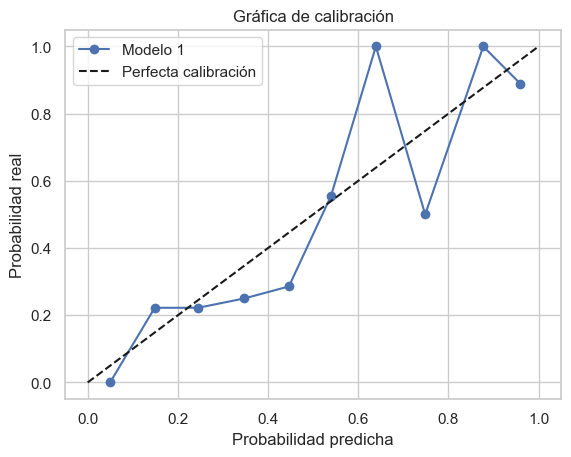

In [31]:
prob_pos = modelo1.predict_proba(X_test_scaled)[:,1]
prob_true, prob_pred = calibration_curve(y_test, prob_pos, n_bins=10)

plt.plot(prob_pred, prob_true, marker='o', label='Modelo 1')
plt.plot([0,1],[0,1],'k--', label='Perfecta calibración')
plt.xlabel('Probabilidad predicha')
plt.ylabel('Probabilidad real')
plt.title('Gráfica de calibración')
plt.legend()
plt.show()


* El modelo sigue de cerca la línea ideal en casi todos los tramos, pero muestra algunas desviaciones, especialmente para valores altos de probabilidad (entre 0.6 y 0.8), donde la curva sube por encima de la ideal (ligera sobre-confianza) y también pequeños saltos cuando hay pocos datos en ciertos bins (a partir de 0.8). 

* Esto indica que el modelo puede estar "bien" calibrado. Las probabilidades que predice pueden interpretarse como frecuencias reales, aunque pueden existir pequeñas áreas donde la probabilidad estimada sea algo más optimista o pesimista que la frecuencia real.

In [32]:
# Obtener probabilidades de la clase positiva
probs = modelo1.predict_proba(X_test_scaled)[:, 1]

# Definir un umbral
umbral = 0.48

# Aplicar umbral para predecir clases
predic_umbral = (probs >= umbral).astype(int)

print("Predicciones con umbral personalizado:", predic_umbral)


Predicciones con umbral personalizado: [1 0 0 1 0 1 0 1 1 0 0 1 0 1 0 0 0 0 0 1 0 1 0 1 0 0 1 0 0 1 1 0 1 0 0 1 1
 0 1 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 1 1 0 0 0 0 1 0 0 0 1
 1 1 0 1 1 0]


### Desempeño del modelo mediante las métricas de gain (ganancia) y lift por decil de probabilidad predicha

In [33]:
# Construimos un DataFrame con probabilidades y clase real
df_gain = pd.DataFrame({
    "y_true": y_test.values,
    "y_prob": predic_proba[:, 1]  # probabilidad de clase positiva
})

# Ordenar por probabilidad descendente (los más "probables positivos" arriba)
df_gain = df_gain.sort_values("y_prob", ascending=False).reset_index(drop=True)

n = len(df_gain)
n_pos = df_gain["y_true"].sum()

# Definimos deciles
df_gain["decile"] = pd.qcut(df_gain.index, q=10, labels=False)

tabla = (
    df_gain
    .groupby("decile")
    .agg(
        n_obs   = ("y_true", "count"),
        n_pos   = ("y_true", "sum")
    )
    .reset_index()
)

tabla["perc_obs"]      = tabla["n_obs"].cumsum() / n
tabla["perc_pos"]      = tabla["n_pos"].cumsum() / n_pos
tabla["gain"]          = tabla["perc_pos"]      # ganancia acumulada
tabla["lift"]          = tabla["gain"] / tabla["perc_obs"]

tabla


,decile,n_obs,n_pos,perc_obs,perc_pos,gain,lift
0,0,8,7,0.1,0.241379,0.241379,2.413793
1,1,8,7,0.2,0.482759,0.482759,2.413793
2,2,8,5,0.3,0.655172,0.655172,2.183908
3,3,8,4,0.4,0.793103,0.793103,1.982759
4,4,8,2,0.5,0.862069,0.862069,1.724138
5,5,8,2,0.6,0.931034,0.931034,1.551724
6,6,8,2,0.7,1.000000,1.000000,1.428571
7,7,8,0,0.8,1.000000,1.000000,1.250000
8,8,8,0,0.9,1.000000,1.000000,1.111111
9,9,8,0,1.0,1.000000,1.000000,1.000000


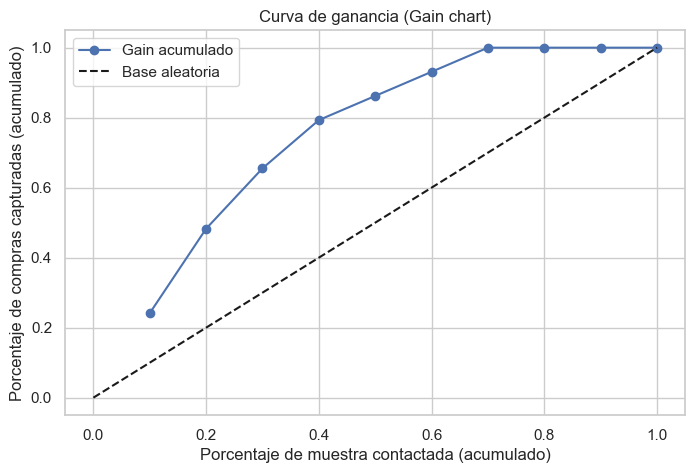

In [34]:
# Gráfico de gain
plt.figure(figsize=(8, 5))
plt.plot(tabla["perc_obs"], tabla["gain"], marker='o', label="Gain acumulado")
plt.plot([0,1],[0,1],'k--', label="Base aleatoria")
plt.xlabel("Porcentaje de muestra contactada (acumulado)")
plt.ylabel("Porcentaje de compras capturadas (acumulado)")
plt.title("Curva de ganancia (Gain chart)")
plt.legend()
plt.grid(True)
plt.show()

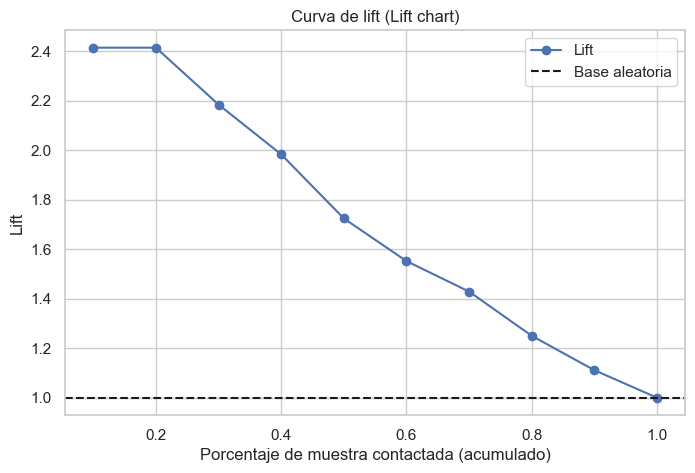

In [35]:
# Gráfica de lift
plt.figure(figsize=(8, 5))
plt.plot(tabla["perc_obs"], tabla["lift"], marker='o', label="Lift")
plt.axhline(1, color='k', linestyle='--', label="Base aleatoria")
plt.xlabel("Porcentaje de muestra contactada (acumulado)")
plt.ylabel("Lift")
plt.title("Curva de lift (Lift chart)")
plt.legend()
plt.grid(True)
plt.show()


* En el primer decil (primer 10% más probable), el modelo captura un 24% de todos los positivos (perc_pos), con un lift de 2.41: identifica más del doble de lo esperado por azar.

* En los dos primeros deciles, ya suma casi el 48% de todos los “compradores” con sólo el 20% de los casos, mostrando un excelente poder de priorización.

* El lift va decreciendo en cada decil, acercándose a 1 (lo esperado por azar) en los últimos deciles: en los menos probables, encontrar un comprador es tan probable como al azar.

* Todos los positivos son capturados hasta el decil 7 (perc_pos = 1.0) a partir de ahí ya solo se agregan negativos.

* Tener un lift alto y una ganancia elevada en los primeros deciles indica que el modelo es útil para identificar, con pocos recursos o acciones dirigidas, la mayor parte de los casos relevantes (compradores).

## Test de Hosmer-Lemeshow

* Compara las proporciones predichas de eventos (por ejemplo, comprar) con las proporciones realmente observadas en grupos (generalmente deciles) de riesgo similar.
* Un valor-p alto (> 0.05) indica que no hay evidencia para rechazar la buena calibración; uno bajo indica que hay diferencias sistemáticas entre lo esperado y lo observado.

In [43]:
probs = modelo1.predict_proba(X_test_scaled)[:, 1]
observed = y_test.values

# Definimos los grupos (deciles)
n_groups = 10
df = pd.DataFrame({'y_true': observed, 'y_prob': probs})
df['group'] = pd.qcut(df['y_prob'], q=n_groups, labels=False)

# Para cada grupo, calculamos eventos esperados y observados
grouped = df.groupby('group')
obs = grouped['y_true'].sum()
exp = grouped['y_prob'].sum()
n = grouped.size()

# Evitamos divisiones por cero
exp = np.where(exp == 0, 1e-10, exp)
n = np.where(n == 0, 1e-10, n)

# Estadístico HL
hl_stat = np.sum(((obs - exp) ** 2) / (exp * (1 - exp / n)))
df_hl = n_groups - 2
p_value = 1 - chi2.cdf(hl_stat, df_hl)

print(f"Hosmer-Lemeshow stat: {hl_stat:.2f}, gl: {df_hl}, p-value: {p_value:.4f}")

Hosmer-Lemeshow stat: 4.94, gl: 8, p-value: 0.7638


* El estadístico calculado (4.94) es mucho menor que el valor crítico para 8 grados de libertad.

* El p-valor (0.7638) es muy alto (mayor que 0.05), lo que significa que no hay evidencia estadísticamente significativa de que el modelo esté mal calibrado.

## Estadístico K-S (Kolmogorov-Smirnov)

* Mide la mayor diferencia entre las distribuciones acumuladas de las probabilidades predichas para las dos clases (0 y 1).

* Se calcula como la máxima distancia vertical entre la curva de la proporción acumulada de positivos y la de negativos respecto a algún umbral de corte.

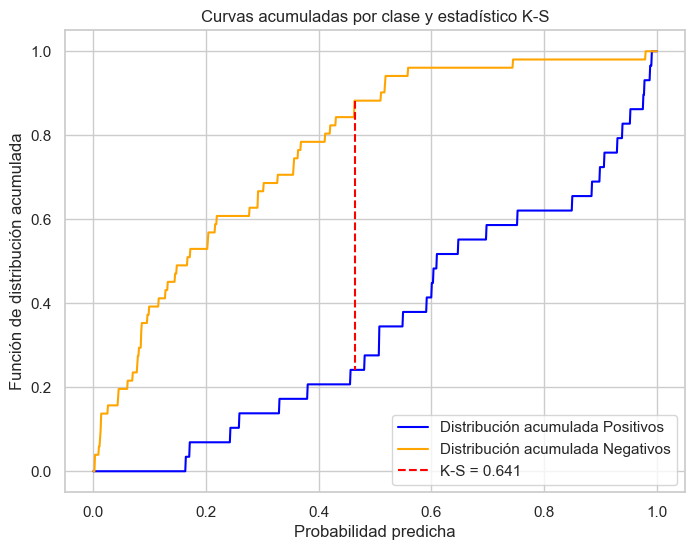

In [40]:
# Separar probabilidades por clase real
probs_pos = prob_pos[y_test == 1]
probs_neg = prob_pos[y_test == 0]

# Calcular función de distribución acumulada (CDF) para cada clase ordenadas ascendentemente
thresholds = np.linspace(0, 1, 1000)
cdf_pos = np.array([np.sum(probs_pos <= t) / len(probs_pos) for t in thresholds])
cdf_neg = np.array([np.sum(probs_neg <= t) / len(probs_neg) for t in thresholds])

# Calcular diferencia entre CDFs (estadístico K-S) y el umbral donde es máxima
ks_statistic = np.max(np.abs(cdf_pos - cdf_neg))
ks_threshold = thresholds[np.argmax(np.abs(cdf_pos - cdf_neg))]

# Graficar ambas curvas
plt.figure(figsize=(8,6))
plt.plot(thresholds, cdf_pos, label="Distribución acumulada Positivos", color="blue")
plt.plot(thresholds, cdf_neg, label="Distribución acumulada Negativos", color="orange")
plt.vlines(ks_threshold, cdf_neg[np.argmax(np.abs(cdf_pos - cdf_neg))], 
           cdf_pos[np.argmax(np.abs(cdf_pos - cdf_neg))], 
           color="red", linestyle="--", label=f"K-S = {ks_statistic:.3f}")

plt.title("Curvas acumuladas por clase y estadístico K-S")
plt.xlabel("Probabilidad predicha")
plt.ylabel("Función de distribución acumulada")
plt.legend()
plt.grid(True)
plt.show()

* Un K-S de 0.641 significa que, en algún umbral de probabilidad, existe una diferencia de 64.1 puntos porcentuales entre la proporción acumulada de verdaderos positivos y la de falsos positivos.

* Un valor como este es muy bueno e indica que el modelo separa muy bien ambas clases: hay un umbral donde la mayoría de los positivos se distinguen claramente de los negativos.

### Reporte de clasificación

In [36]:
predic = modelo1.predict(X_test_scaled)
print("=== Modelo 1: ===")
print("Matriz de confusión:\n", confusion_matrix(y_test, predic))

print(classification_report(y_test, predic))

tn, fp, fn, tp = confusion_matrix(y_test, predic).ravel()

specificity = tn / (tn + fp)  # TNR
mcc = matthews_corrcoef(y_test, predic)

print(f"Specificity (TNR): {specificity:.2f}")
print(f"MCC:               {mcc:.2f}")

=== Modelo 1: ===
Matriz de confusión:
 [[45  6]
 [ 8 21]]
              precision    recall  f1-score   support

           0       0.85      0.88      0.87        51
           1       0.78      0.72      0.75        29

    accuracy                           0.82        80
   macro avg       0.81      0.80      0.81        80
weighted avg       0.82      0.82      0.82        80

Specificity (TNR): 0.88
MCC:               0.62


* Accuracy (Exactitud): 0.82. El modelo clasifica correctamente el 82% de los casos totales, una muy buena tasa para este contexto.
* Precision para clase 1 (compra): 0.78. De cada 100 predicciones "compra", aproximadamente 78 son correctas.
* Recall para clase 1 (sensibilidad): 0.72. El modelo recupera el 72% de todos los compradores reales, aunque deja escapar el 28%.
* F1-score clase 1: 0.75. Buen balance entre precisión y recall.
* Specificity (TNR): 0.88. El modelo identifica correctamente al 88% de quienes no compran, muy confiable al descartar negativos.
* MCC (Matthews Correlation Coefficient o phi coefficient): 0.62. Valor superior a 0.5 indica buena capacidad discriminativa incluso en presencia de cierto desbalance de clases.

* El modelo es confiable y equilibrado: tiene buena precisión y recall tanto para compradores como para no compradores, con bajo porcentaje de falsos positivos.

### Curva ROC

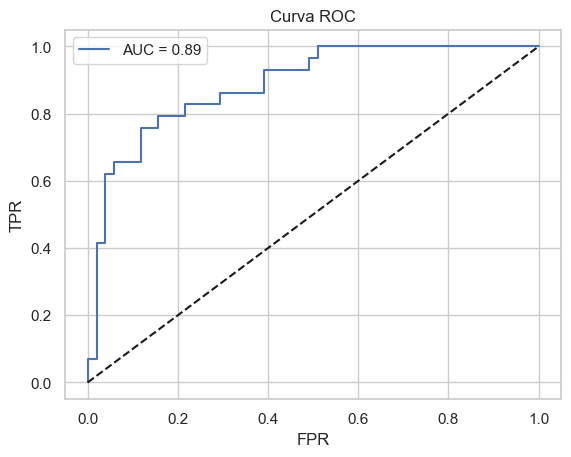

In [37]:
fpr, tpr, thresholds = roc_curve(y_test, predic_proba_df["P(Purchased=1)"])
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('Curva ROC')
plt.legend()
plt.show()

El AUC-ROC de 0.89 confirma que la capacidad discriminante del modelo es alta, independientemente del umbral usado.

In [38]:
fpr, tpr, thresholds = roc_curve(y_test, predic_proba_df["P(Purchased=1)"])
# thresholds es el array de puntos de corte probados

# Ejemplo: seleccionar el umbral que maximiza la suma (TPR - FPR)
youden_index = tpr - fpr
best_threshold = thresholds[youden_index.argmax()]
print("Mejor umbral según índice de Youden:", best_threshold)


Mejor umbral según índice de Youden: 0.4809456738239916


Este umbral es el que logra el mejor balance entre sensibilidad (recall para clase 1) y especificidad (TNR para clase 0).

In [39]:
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

rows = []
for thr in thresholds:
    y_pred_thr = (predic_proba[:, 1] >= thr).astype(int)

    acc  = accuracy_score(y_test, y_pred_thr)
    prec = precision_score(y_test, y_pred_thr)
    rec  = recall_score(y_test, y_pred_thr)

    rows.append({
        "threshold": thr,
        "accuracy":  acc,
        "precision": prec,
        "recall":    rec
    })

df_thr = pd.DataFrame(rows)
df_thr


,threshold,accuracy,precision,recall
0,0.3,0.7375,0.595238,0.862069
1,0.4,0.7875,0.676471,0.793103
2,0.5,0.8250,0.777778,0.724138
3,0.6,0.8125,0.888889,0.551724
4,0.7,0.7625,0.857143,0.413793


# Ejercicio.

A partir del modelo 1, construya un Modelo 2 utilizando regresión logística con penalización y compare sus resultados con el Modelo 1 en términos de: coeficientes y odds ratio, métricas de desempeño y cualquier diferencia observable en la magnitud de los efectos.

Finalmente, interprete brevemente si la regularización modifica la estabilidad o el comportamiento del modelo. Pruebe con distintos valores de C.